# TP2 — Vision par Ordinateur

**Filière : IASD — EST Nador**  
**Année : 2026/2027**

Ce notebook reprend les exercices 1 à 16 du TP2 et contient les sorties exécutées.

> Le TP demande un fichier `image.jpg`. Si ce fichier n'est pas présent, le notebook génère automatiquement une petite image de démonstration afin que toutes les cellules restent exécutables. Vous pouvez remplacer `image.jpg` par votre propre image sans modifier le reste du notebook.


## 0. Installation et importation

In [1]:
# À exécuter une seule fois si nécessaire :
# %pip install opencv-python numpy matplotlib

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 45
plt.rcParams["savefig.dpi"] = 45
plt.rcParams["figure.figsize"] = (5, 3.2)

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)


OpenCV : 4.13.0
NumPy  : 2.3.5


## Préparation de `image.jpg`

In [2]:
image_path = Path("image.jpg")

if not image_path.exists():
    # Image couleur de démonstration, créée uniquement si image.jpg est absente.
    h, w = 240, 320
    y = np.linspace(0, 1, h)[:, None]
    x = np.linspace(0, 1, w)[None, :]

    B = np.tile((255 * x).astype(np.uint8), (h, 1))
    G = np.tile((255 * y).astype(np.uint8), (1, w))
    R = (255 * (1 - 0.55*x - 0.35*y)).clip(0, 255).astype(np.uint8)

    demo = np.dstack([B, G, R])
    cv2.rectangle(demo, (25, 35), (130, 125), (30, 30, 230), -1)
    cv2.circle(demo, (235, 85), 48, (40, 220, 40), -1)
    cv2.line(demo, (25, 200), (295, 155), (230, 70, 20), 10)
    cv2.putText(demo, "TP2", (125, 215), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (250, 250, 250), 2)
    cv2.imwrite(str(image_path), demo)
    print("image.jpg générée automatiquement.")
else:
    print("image.jpg trouvée.")

image = cv2.imread(str(image_path))
if image is None:
    raise FileNotFoundError("Impossible de charger image.jpg")

print("Dimensions :", image.shape)


image.jpg générée automatiquement.
Dimensions : (240, 320, 3)


---
# Exercice 1 — Chargement et affichage d'une image

### Objectif
Charger l'image, vérifier son existence, afficher ses dimensions et l'afficher.


Image chargée : True
Shape : (240, 320, 3)


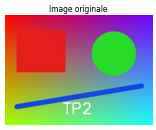

In [3]:
print("Image chargée :", image_path.exists())
print("Shape :", image.shape)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Image originale")
plt.axis("off")
plt.show()


### Réponse à la question
Pour une image de **1920 × 1080** :

\[
1920 \times 1080 = 2\,073\,600
\]

Donc l'image contient **2 073 600 pixels**.


---
# Exercice 2 — Passage en niveaux de gris


Dimensions couleur : (240, 320, 3)
Dimensions gris    : (240, 320)


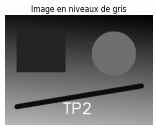

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Dimensions couleur :", image.shape)
print("Dimensions gris    :", gray.shape)

plt.imshow(gray, cmap="gray")
plt.title("Image en niveaux de gris")
plt.axis("off")
plt.show()


### Réponse
Une image couleur possède trois dimensions : **hauteur × largeur × 3 canaux**.  
Une image en niveaux de gris possède seulement **hauteur × largeur**, car chaque pixel est représenté par une seule intensité comprise entre 0 et 255.


In [5]:
x, y = 100, 150
print(f"Valeur du pixel gray[{y}, {x}] =", int(gray[y, x]))


Valeur du pixel gray[150, 100] = 149


Cette valeur représente **l'intensité lumineuse** du pixel : 0 = noir, 255 = blanc.

---
# Exercice 3 — Manipulation des canaux RGB


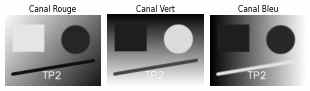

Moyennes R, G, B : 134.25 127.72 114.07


In [6]:
B, G, R = cv2.split(image)

fig, axes = plt.subplots(1, 3, figsize=(7, 2.4))
for ax, channel, title in zip(
    axes, [R, G, B], ["Canal Rouge", "Canal Vert", "Canal Bleu"]
):
    ax.imshow(channel, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Moyennes R, G, B :", round(float(R.mean()), 2),
      round(float(G.mean()), 2), round(float(B.mean()), 2))


### Réponse
Dans une région rouge, la composante **R** doit être importante. Cette région apparaît donc claire dans le canal rouge, tandis qu'elle est généralement plus sombre dans les canaux vert et bleu.


---
# Exercice 4 — Calcul et affichage de l'histogramme


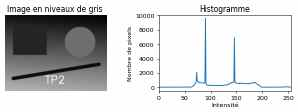

Intensité moyenne : 128.13
Écart-type         : 39.52


In [7]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(7, 2.6))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Image en niveaux de gris")
axes[0].axis("off")

axes[1].plot(hist)
axes[1].set_title("Histogramme")
axes[1].set_xlabel("Intensité")
axes[1].set_ylabel("Nombre de pixels")
axes[1].set_xlim([0, 255])
plt.tight_layout()
plt.show()

mean_intensity = float(gray.mean())
std_intensity = float(gray.std())
print(f"Intensité moyenne : {mean_intensity:.2f}")
print(f"Écart-type         : {std_intensity:.2f}")


### Analyse
- Une concentration à gauche indique une image plutôt sombre.
- Une concentration à droite indique une image plutôt claire.
- Un histogramme étalé sur une grande partie de `[0, 255]` traduit généralement un contraste plus important.


---
# Exercice 5 — Histogrammes des trois canaux RGB


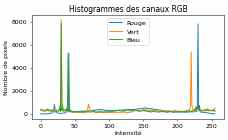

Moyennes : {'Rouge': 134.25, 'Vert': 127.72, 'Bleu': 114.07}
Canal moyen dominant : Rouge


In [8]:
hist_R = cv2.calcHist([R], [0], None, [256], [0, 256])
hist_G = cv2.calcHist([G], [0], None, [256], [0, 256])
hist_B = cv2.calcHist([B], [0], None, [256], [0, 256])

plt.figure(figsize=(5.5, 3))
plt.plot(hist_R, label="Rouge")
plt.plot(hist_G, label="Vert")
plt.plot(hist_B, label="Bleu")
plt.title("Histogrammes des canaux RGB")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.legend()
plt.show()

means = {"Rouge": float(R.mean()), "Vert": float(G.mean()), "Bleu": float(B.mean())}
dominant = max(means, key=means.get)
print("Moyennes :", {k: round(v, 2) for k, v in means.items()})
print("Canal moyen dominant :", dominant)


### Analyse
Le canal dominant peut être estimé en comparant les distributions et les intensités moyennes. Le résultat doit être cohérent avec les couleurs majoritaires visibles dans l'image.


---
# Exercice 6 — Normalisation / étirement du contraste


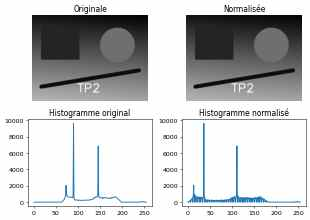

Original : min = 63 max = 253
Normalisé: min = 0 max = 255


In [9]:
normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_normalized = cv2.calcHist([normalized], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes[0,0].imshow(gray, cmap="gray")
axes[0,0].set_title("Originale")
axes[0,0].axis("off")
axes[0,1].imshow(normalized, cmap="gray")
axes[0,1].set_title("Normalisée")
axes[0,1].axis("off")
axes[1,0].plot(hist_original)
axes[1,0].set_title("Histogramme original")
axes[1,1].plot(hist_normalized)
axes[1,1].set_title("Histogramme normalisé")
plt.tight_layout()
plt.show()

print("Original : min =", int(gray.min()), "max =", int(gray.max()))
print("Normalisé: min =", int(normalized.min()), "max =", int(normalized.max()))


### Réponse
La normalisation améliore le contraste lorsque l'image utilise seulement une petite partie de la dynamique, car elle étire les valeurs pour rapprocher le minimum de 0 et le maximum de 255.


---
# Exercice 7 — Égalisation de l'histogramme


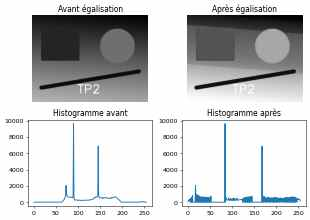

In [10]:
equalized = cv2.equalizeHist(gray)
hist1 = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([equalized], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes[0,0].imshow(gray, cmap="gray")
axes[0,0].set_title("Avant égalisation")
axes[0,0].axis("off")
axes[0,1].imshow(equalized, cmap="gray")
axes[0,1].set_title("Après égalisation")
axes[0,1].axis("off")
axes[1,0].plot(hist1)
axes[1,0].set_title("Histogramme avant")
axes[1,1].plot(hist2)
axes[1,1].set_title("Histogramme après")
plt.tight_layout()
plt.show()


### Réponses
1. Le contraste est souvent amélioré, surtout lorsque les niveaux sont concentrés.
2. Certains détails deviennent plus visibles.
3. **Normalisation** : étirement linéaire des intensités. **Égalisation** : redistribution basée sur l'histogramme cumulé.
4. Non. L'égalisation peut parfois amplifier le bruit ou donner un rendu visuellement trop contrasté.


---
# Exercice 8 — Binarisation par seuillage


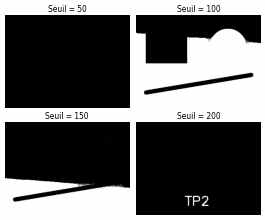

Nombre de pixels blancs avec T=128 : 41623
Nombre de pixels noirs  avec T=128 : 35177


In [11]:
T = 128
_, binary = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)

seuils = [50, 100, 150, 200]
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
for ax, threshold in zip(axes.ravel(), seuils):
    _, img_bin = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    ax.imshow(img_bin, cmap="gray")
    ax.set_title(f"Seuil = {threshold}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Nombre de pixels blancs avec T=128 :", int(np.count_nonzero(binary == 255)))
print("Nombre de pixels noirs  avec T=128 :", int(np.count_nonzero(binary == 0)))


### Réponses
- Le meilleur seuil dépend de l'image et de l'objet à séparer.
- Si le seuil est trop faible, beaucoup de pixels deviennent blancs.
- Si le seuil est trop élevé, beaucoup de pixels deviennent noirs.


---
# Exercice 9 — Seuillage automatique d'Otsu


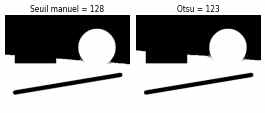

Seuil calculé par Otsu : 123.0


In [12]:
T_otsu, binary_otsu = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
_, binary_128 = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.8))
axes[0].imshow(binary_128, cmap="gray")
axes[0].set_title("Seuil manuel = 128")
axes[0].axis("off")
axes[1].imshow(binary_otsu, cmap="gray")
axes[1].set_title(f"Otsu = {T_otsu:.0f}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Seuil calculé par Otsu :", T_otsu)


### Réponse
Otsu choisit automatiquement un seuil à partir de la distribution des intensités, alors que 128 est une valeur fixée manuellement.

---
# Exercice 10 — Transformations géométriques


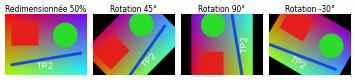

Taille originale : (240, 320)
Taille réduite   : (120, 160)


In [13]:
height, width = image.shape[:2]

resized = cv2.resize(image, (width // 2, height // 2))

rotations = {}
for angle in [45, 90, -30]:
    center = (width // 2, height // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1)
    rotations[angle] = cv2.warpAffine(image, M, (width, height))

fig, axes = plt.subplots(1, 4, figsize=(8, 2.4))
axes[0].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0].set_title("Redimensionnée 50%")
axes[0].axis("off")
for ax, angle in zip(axes[1:], [45, 90, -30]):
    ax.imshow(cv2.cvtColor(rotations[angle], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Rotation {angle}°")
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Taille originale :", image.shape[:2])
print("Taille réduite   :", resized.shape[:2])


### Analyse
La rotation change l'orientation de l'image autour du centre. Les zones créées en dehors de l'image originale sont remplies par défaut avec des valeurs noires.


---
# Exercice 11 — Translation


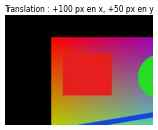

In [14]:
M = np.float32([
    [1, 0, 100],
    [0, 1, 50]
])
translated = cv2.warpAffine(image, M, (width, height))

plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.title("Translation : +100 px en x, +50 px en y")
plt.axis("off")
plt.show()


### Réponses
- **100** représente le déplacement horizontal vers la droite.
- **50** représente le déplacement vertical vers le bas.
- Des valeurs négatives déplacent l'image vers la gauche ou vers le haut.


---
# Exercice 12 — Filtre moyenneur


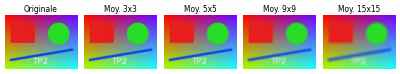

In [15]:
mean_results = {
    3: cv2.blur(image, (3, 3)),
    5: cv2.blur(image, (5, 5)),
    9: cv2.blur(image, (9, 9)),
    15: cv2.blur(image, (15, 15)),
}

fig, axes = plt.subplots(1, 5, figsize=(9, 2.3))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

for ax, k in zip(axes[1:], [3, 5, 9, 15]):
    ax.imshow(cv2.cvtColor(mean_results[k], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Moy. {k}x{k}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Analyse
Lorsque la taille du noyau augmente, le lissage devient plus fort : le bruit et les petites fluctuations diminuent, mais les contours et les détails deviennent plus flous.


---
# Exercice 13 — Filtre gaussien


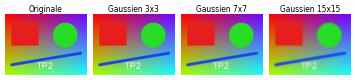

In [16]:
gaussian_results = {
    3: cv2.GaussianBlur(image, (3, 3), 0),
    7: cv2.GaussianBlur(image, (7, 7), 0),
    15: cv2.GaussianBlur(image, (15, 15), 0),
}

fig, axes = plt.subplots(1, 4, figsize=(8, 2.4))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

for ax, k in zip(axes[1:], [3, 7, 15]):
    ax.imshow(cv2.cvtColor(gaussian_results[k], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Gaussien {k}x{k}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Comparaison
Plus le noyau gaussien est grand, plus le lissage est important. Le filtre gaussien pondère davantage les pixels proches du centre, ce qui produit généralement un flou plus naturel qu'une moyenne uniforme.


---
# Exercice 14 — Filtre médian


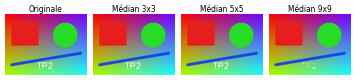

In [17]:
median_results = {
    3: cv2.medianBlur(image, 3),
    5: cv2.medianBlur(image, 5),
    9: cv2.medianBlur(image, 9),
}

fig, axes = plt.subplots(1, 4, figsize=(8, 2.4))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

for ax, k in zip(axes[1:], [3, 5, 9]):
    ax.imshow(cv2.cvtColor(median_results[k], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Médian {k}x{k}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Réponses
1. Le moyenneur remplace un pixel par la moyenne du voisinage ; le médian utilise la médiane.
2. Le filtre médian préserve généralement mieux les contours, surtout en présence de bruit impulsionnel.
3. Quand le noyau augmente, le bruit diminue davantage mais certains détails fins peuvent disparaître.


---
# Exercice 15 — Comparaison des trois filtres


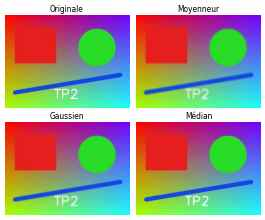

In [18]:
mean = cv2.blur(image, (5, 5))
gaussian = cv2.GaussianBlur(image, (5, 5), 0)
median = cv2.medianBlur(image, 5)

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
for ax, img_show, title in zip(
    axes.ravel(),
    [image, mean, gaussian, median],
    ["Originale", "Moyenneur", "Gaussien", "Médian"],
):
    ax.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Tableau de synthèse

| Filtre | Type | Objectif principal | Effet sur les contours |
|---|---|---|---|
| Moyenneur | Linéaire | Lissage / réduction de fluctuations | Floute facilement les contours |
| Gaussien | Linéaire | Lissage pondéré / bruit gaussien | Préserve mieux que le moyenneur, mais floute |
| Médian | Non linéaire | Bruit impulsionnel « poivre et sel » | Préserve généralement mieux les contours |


---
# Exercice 16 — Mini-projet : chaîne complète de traitement

Chaîne demandée :

**Image originale → Niveaux de gris → Histogramme → Amélioration du contraste → Binarisation → Filtrage → Image finale**


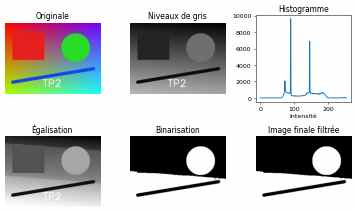

Chaîne complète exécutée avec succès.
Pixels blancs finaux : 38250
Pixels noirs finaux  : 38550


In [19]:
# Étape 1 — Charger l'image
pipeline_image = cv2.imread("image.jpg")

# Étape 2 — Conversion en niveaux de gris
pipeline_gray = cv2.cvtColor(pipeline_image, cv2.COLOR_BGR2GRAY)

# Étape 3 — Histogramme
pipeline_hist = cv2.calcHist([pipeline_gray], [0], None, [256], [0, 256])

# Étape 4 — Égalisation
pipeline_equalized = cv2.equalizeHist(pipeline_gray)

# Étape 5 — Binarisation
_, pipeline_binary = cv2.threshold(
    pipeline_equalized, 128, 255, cv2.THRESH_BINARY
)

# Étape 6 — Filtrage médian
pipeline_filtered = cv2.medianBlur(pipeline_binary, 5)

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
axes[0,0].imshow(cv2.cvtColor(pipeline_image, cv2.COLOR_BGR2RGB))
axes[0,0].set_title("Originale")
axes[0,0].axis("off")

axes[0,1].imshow(pipeline_gray, cmap="gray")
axes[0,1].set_title("Niveaux de gris")
axes[0,1].axis("off")

axes[0,2].plot(pipeline_hist)
axes[0,2].set_title("Histogramme")
axes[0,2].set_xlabel("Intensité")

axes[1,0].imshow(pipeline_equalized, cmap="gray")
axes[1,0].set_title("Égalisation")
axes[1,0].axis("off")

axes[1,1].imshow(pipeline_binary, cmap="gray")
axes[1,1].set_title("Binarisation")
axes[1,1].axis("off")

axes[1,2].imshow(pipeline_filtered, cmap="gray")
axes[1,2].set_title("Image finale filtrée")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

print("Chaîne complète exécutée avec succès.")
print("Pixels blancs finaux :", int(np.count_nonzero(pipeline_filtered == 255)))
print("Pixels noirs finaux  :", int(np.count_nonzero(pipeline_filtered == 0)))


---
# Questions finales — Réponses

**Q1. Différence entre image binaire, niveaux de gris et RGB ?**  
- Binaire : 2 valeurs principales, généralement 0 et 255.
- Niveaux de gris : une intensité par pixel, généralement de 0 à 255.
- RGB : trois composantes de couleur par pixel.

**Q2. Pourquoi une image RGB possède-t-elle trois canaux ?**  
Parce qu'elle représente la couleur à l'aide des composantes Rouge, Vert et Bleu.

**Q3. Différence entre un histogramme et une image ?**  
L'image conserve la position spatiale de chaque pixel. L'histogramme compte seulement combien de pixels possèdent chaque intensité.

**Q4. Pourquoi deux images différentes peuvent-elles avoir le même histogramme ?**  
Parce que l'histogramme ne contient pas l'information de position spatiale des pixels.

**Q5. Différence entre normalisation et égalisation ?**  
La normalisation étire linéairement la dynamique ; l'égalisation redistribue les intensités selon la distribution cumulée.

**Q6. Effet d'un seuil trop élevé ?**  
Trop de pixels deviennent noirs et des régions utiles peuvent disparaître.

**Q7. Différence entre moyenneur et médian ?**  
Le moyenneur utilise la moyenne ; le médian utilise la valeur médiane du voisinage.

**Q8. Pourquoi le médian est-il adapté au bruit poivre et sel ?**  
Les valeurs extrêmes isolées influencent peu la médiane, donc le filtre supprime efficacement les impulsions noires/blanches.

**Q9. Effet de l'augmentation de la taille du noyau ?**  
Le lissage augmente, mais les détails fins et parfois les contours diminuent.

**Q10. Quand choisir chaque filtre ?**  
- **Moyenneur** : lissage simple quand la perte de netteté est acceptable.
- **Gaussien** : lissage plus naturel et réduction de bruit de type gaussien.
- **Médian** : bruit impulsionnel / poivre et sel et meilleur maintien des contours.
